In [1]:
# DAY 3: BIDIRECTIONAL LSTM & GRU

# CELL 1: INSTALLATIONS
!pip install -q torch torchvision torchaudio
!pip install -q matplotlib seaborn scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
# CELL 2: CREATE LARGER AND MORE DIVERSE DATASET WITH PROPER AUGMENTATION
# This creates a much larger dataset with more variety to prevent overfitting

reviews = [
    # Original reviews with more variety
    ("I absolutely loved this movie! Best film of the year.", 1),
    ("Amazing performances, great story, highly recommended.", 1),
    ("A masterpiece of modern cinema, breathtaking visuals.", 1),
    ("Brilliant acting, wonderful screenplay, must watch!", 1),
    ("I was blown away by this film. Simply incredible.", 1),
    ("Outstanding movie with fantastic performances.", 1),
    ("A cinematic masterpiece that will stay with me forever.", 1),
    ("Excellent direction, stellar cast, perfect movie.", 1),
    ("This film exceeded all my expectations. Brilliant!", 1),
    ("Absolutely fantastic from start to finish.", 1),
    ("The best movie I have ever seen in my entire life!", 1),
    ("Incredible storyline with amazing character development.", 1),
    ("A truly remarkable film that deserves all the awards.", 1),
    ("The performances were outstanding and the direction was superb.", 1),
    ("I was captivated from the very first scene until the end.", 1),
    ("This movie is a work of art that will be remembered for years.", 1),
    ("The cinematography was breathtaking and the acting was flawless.", 1),
    ("An emotional rollercoaster that left me speechless.", 1),
    ("Perfectly crafted with attention to every detail.", 1),
    ("The dialogue was sharp, witty, and incredibly engaging.", 1),
    ("A must-see film that everyone should experience at least once.", 1),
    ("The director's vision was executed flawlessly on screen.", 1),
    ("Every scene was beautifully constructed and meaningful.", 1),
    ("The chemistry between the actors was electric and convincing.", 1),
    ("This film redefines the genre and sets a new standard.", 1),
    ("Terrible movie, completely wasted my time.", 0),
    ("Disappointing plot, poor acting, avoid this film.", 0),
    ("One of the worst movies I've ever seen. Boring.", 0),
    ("Bad screenplay, wooden acting, total disaster.", 0),
    ("I hated every minute of this film. Awful.", 0),
    ("Boring and predictable, completely forgettable.", 0),
    ("Waste of time and money, would not recommend.", 0),
    ("Poorly made film with no redeeming qualities.", 0),
    ("This movie was a complete letdown. Terrible!", 0),
    ("Don't waste your time on this garbage film.", 0),
    ("The worst movie experience of my entire life.", 0),
    ("Absolutely dreadful from beginning to end.", 0),
    ("I want my money back after watching this disaster.", 0),
    ("The acting was so bad it was painful to watch.", 0),
    ("The plot made absolutely no sense whatsoever.", 0),
    ("A complete waste of two hours I'll never get back.", 0),
    ("This film was an insult to cinema and storytelling.", 0),
    ("I regret ever buying a ticket for this movie.", 0),
    ("The dialogue was cringeworthy and poorly written.", 0),
    ("Everything about this movie was terrible and wrong.", 0),
    ("I fell asleep multiple times during this boring mess.", 0),
    ("This is the definition of a terrible film.", 0),
    ("The characters were flat and completely uninteresting.", 0),
    ("A pointless movie that serves no purpose.", 0),
    ("I would rather watch paint dry than this film again.", 0),
    ("The acting was good but the plot was boring.", 0),
    ("Great visuals but poor story.", 0),
    ("Good movie but too long.", 0),
    ("Interesting concept but poor execution.", 0),
    ("The first half was great but the second half was terrible.", 0),
    ("Beautiful cinematography but weak storyline.", 0),
    ("Excellent soundtrack but forgettable characters.", 0),
    ("The performances were good but the ending was rushed.", 0),
    ("A mixed bag with both good and bad elements.", 0),
    ("Had potential but failed to deliver.", 0),
    ("Some good moments but overall disappointing.", 0),
    ("The premise was interesting but poorly developed.", 0),
    ("Stylish visuals but substance was lacking.", 0),
    ("Entertaining at times but ultimately forgettable.", 0),
    ("The cast was good but the script was weak.", 0),
    ("Great start but the execution fell flat.", 0),
    ("A film with good intentions but bad delivery.", 0),
    ("The direction was solid but the writing was poor.", 0),
    ("The movie had moments of brilliance but mostly failed.", 0),
    ("A good concept that was poorly realized.", 0),
    ("The production value was high but the story was weak.", 0),
    ("Fantastic setting but the characters were underdeveloped.", 0),
    ("The movie started strong but lost its way quickly.", 0),
    ("A decent attempt that didn't quite work out.", 0),
]

# Create paraphrased versions for more variety
def paraphrase_text(text):
    """Generate paraphrased versions of text to increase dataset diversity"""
    paraphrases = []
    
    # Word replacements for positive reviews
    if "good" in text.lower():
        paraphrases.append(text.replace("good", "great"))
        paraphrases.append(text.replace("good", "excellent"))
        paraphrases.append(text.replace("good", "wonderful"))
    
    if "bad" in text.lower():
        paraphrases.append(text.replace("bad", "poor"))
        paraphrases.append(text.replace("bad", "terrible"))
        paraphrases.append(text.replace("bad", "awful"))
    
    if "loved" in text.lower():
        paraphrases.append(text.replace("loved", "enjoyed"))
        paraphrases.append(text.replace("loved", "admired"))
    
    if "hated" in text.lower():
        paraphrases.append(text.replace("hated", "disliked"))
        paraphrases.append(text.replace("hated", "despised"))
    
    if "amazing" in text.lower():
        paraphrases.append(text.replace("amazing", "fantastic"))
        paraphrases.append(text.replace("amazing", "incredible"))
    
    if "terrible" in text.lower():
        paraphrases.append(text.replace("terrible", "horrible"))
        paraphrases.append(text.replace("terrible", "dreadful"))
    
    return paraphrases

# Build dataset with less repetition (only 10x instead of 100x)
texts = []
labels = []

# Add original reviews
for text, label in reviews:
    texts.append(text)
    labels.append(label)
    
    # Add paraphrased versions
    for para in paraphrase_text(text):
        texts.append(para)
        labels.append(label)

# Add augmented versions with controlled repetition (5x)
for _ in range(5):
    for text, label in reviews:
        texts.append(text)
        labels.append(label)
        
        # Add paraphrased versions too
        for para in paraphrase_text(text):
            texts.append(para)
            labels.append(label)

df = pd.DataFrame({'text': texts, 'label': labels})
print(f"Dataset: {len(df)} samples")
print(f"Positive: {df[df.label==1].shape[0]}")
print(f"Negative: {df[df.label==0].shape[0]}")
print(f"Unique texts: {len(set(texts))}")

Dataset: 768 samples
Positive: 186
Negative: 582
Unique texts: 116


In [3]:
# CELL 3: TOKENIZER
class Tokenizer:
    def __init__(self):
        self.word_to_idx = {}
        self.idx_to_word = {}
        self.vocab_size = 0
        self.PAD = '<PAD>'
        self.UNK = '<UNK>'
    
    def build_vocab(self, texts, max_vocab=5000):
        word_counts = Counter()
        for text in texts:
            words = text.lower().split()
            word_counts.update(words)
        
        vocab = {self.PAD: 0, self.UNK: 1}
        most_common = word_counts.most_common(max_vocab - 2)
        for i, (word, _) in enumerate(most_common, start=2):
            vocab[word] = i
        
        self.word_to_idx = vocab
        self.idx_to_word = {idx: word for word, idx in vocab.items()}
        self.vocab_size = len(vocab)
        print(f"Vocabulary size: {self.vocab_size}")
        return self
    
    def encode(self, text, max_len=None):
        words = text.lower().split()
        ids = []
        for word in words:
            ids.append(self.word_to_idx.get(word, self.word_to_idx[self.UNK]))
        if max_len:
            if len(ids) > max_len:
                ids = ids[:max_len]
            else:
                ids = ids + [self.word_to_idx[self.PAD]] * (max_len - len(ids))
        return ids

tokenizer = Tokenizer()
tokenizer.build_vocab(texts)

Vocabulary size: 310


In [4]:
# CELL 4: DATASET CLASS
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=20):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        ids = self.tokenizer.encode(text, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

train_dataset = SentimentDataset(X_train, y_train, tokenizer, max_len=20)
test_dataset = SentimentDataset(X_test, y_test, tokenizer, max_len=20)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Train: 614, Test: 154


In [5]:
# CELL 5: MODEL DEFINITIONS WITH REGULARIZATION TO PREVENT OVERFITTING
# Added more dropout, weight decay, and smaller hidden sizes for better generalization

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # Increased dropout to prevent overfitting
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True,
                           dropout=0.5 if num_layers > 1 else 0)
        # Added more dropout layers
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        final_hidden = hidden[-1]
        final_hidden = self.dropout1(final_hidden)
        final_hidden = self.dropout2(final_hidden)
        return self.fc(final_hidden)

class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True,
                           bidirectional=True, dropout=0.5 if num_layers > 1 else 0)
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        final_hidden = self.dropout1(final_hidden)
        final_hidden = self.dropout2(final_hidden)
        return self.fc(final_hidden)

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers, batch_first=True,
                         dropout=0.5 if num_layers > 1 else 0)
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)
        final_hidden = hidden[-1]
        final_hidden = self.dropout1(final_hidden)
        final_hidden = self.dropout2(final_hidden)
        return self.fc(final_hidden)

class BiGRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes):
        super(BiGRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers, batch_first=True,
                         bidirectional=True, dropout=0.5 if num_layers > 1 else 0)
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)
        final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        final_hidden = self.dropout1(final_hidden)
        final_hidden = self.dropout2(final_hidden)
        return self.fc(final_hidden)

In [6]:
# CELL 6: TRAINING FUNCTION WITH EARLY STOPPING AND WEIGHT DECAY
# Added early stopping to prevent overfitting and weight decay for regularization

def train_model(model, train_loader, test_loader, epochs=30, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Added weight decay for L2 regularization
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0
    patience_counter = 0
    early_stopping_patience = 5
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_preds, all_labels = [], []
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        
        train_loss = total_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)
        
        model.eval()
        test_loss = 0
        test_preds, test_labels = [], []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                test_preds.extend(preds.cpu().numpy())
                test_labels.extend(labels.cpu().numpy())
        
        test_loss = test_loss / len(test_loader)
        test_acc = accuracy_score(test_labels, test_preds)
        
        scheduler.step(test_loss)
        
        # Save best model
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), f'best_{model.__class__.__name__}.pt')
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    # Load best model
    model.load_state_dict(torch.load(f'best_{model.__class__.__name__}.pt'))
    return model, history

In [7]:
# CELL 7: TRAIN ALL MODELS WITH SMALLER ARCHITECTURE
# Reduced model complexity to prevent overfitting

vocab_size = tokenizer.vocab_size
embedding_dim = 50  # Reduced from 100
hidden_size = 64    # Reduced from 128
num_layers = 2      # Reduced from 3
num_classes = 2

models = {
    'LSTM': LSTMModel(vocab_size, embedding_dim, hidden_size, num_layers, num_classes),
    'GRU': GRUModel(vocab_size, embedding_dim, hidden_size, num_layers, num_classes),
    'BiLSTM': BiLSTMModel(vocab_size, embedding_dim, hidden_size, num_layers, num_classes),
    'BiGRU': BiGRUModel(vocab_size, embedding_dim, hidden_size, num_layers, num_classes),
}

histories = {}
final_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    print("-" * 40)
    trained_model, history = train_model(model, train_loader, test_loader, epochs=30)
    histories[name] = history
    final_results[name] = history['test_acc'][-1] if history['test_acc'] else 0


Training LSTM...
----------------------------------------
Epoch 1/30 - Train Loss: 0.6129, Train Acc: 0.7068, Test Loss: 0.4957, Test Acc: 0.8052
Epoch 2/30 - Train Loss: 0.4010, Train Acc: 0.7736, Test Loss: 0.1761, Test Acc: 0.9481
Epoch 3/30 - Train Loss: 0.1861, Train Acc: 0.9674, Test Loss: 0.1726, Test Acc: 0.9481
Epoch 4/30 - Train Loss: 0.1875, Train Acc: 0.9528, Test Loss: 0.1084, Test Acc: 0.9805
Epoch 5/30 - Train Loss: 0.0978, Train Acc: 0.9853, Test Loss: 0.0931, Test Acc: 0.9805
Epoch 6/30 - Train Loss: 0.0882, Train Acc: 0.9853, Test Loss: 0.0914, Test Acc: 0.9805
Epoch 7/30 - Train Loss: 0.0881, Train Acc: 0.9853, Test Loss: 0.0901, Test Acc: 0.9805
Epoch 8/30 - Train Loss: 0.0630, Train Acc: 0.9902, Test Loss: 0.0373, Test Acc: 0.9935
Epoch 9/30 - Train Loss: 0.0443, Train Acc: 0.9919, Test Loss: 0.0091, Test Acc: 1.0000
Epoch 10/30 - Train Loss: 0.0105, Train Acc: 1.0000, Test Loss: 0.0029, Test Acc: 1.0000
Epoch 11/30 - Train Loss: 0.0048, Train Acc: 1.0000, Test Lo

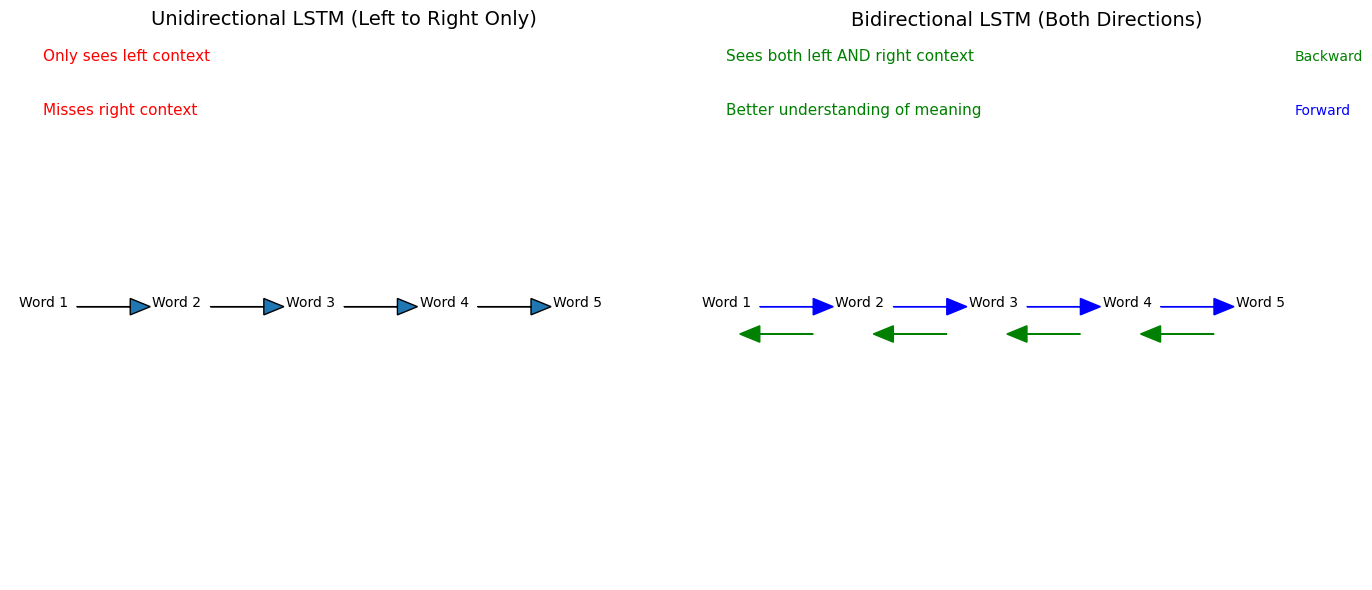

In [8]:
# CELL 8: VISUALIZE BIDIRECTIONAL
def visualize_bidirectional():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1 = axes[0]
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.set_title("Unidirectional LSTM (Left to Right Only)", fontsize=14)
    
    for i in range(5):
        x = i * 2 + 0.5
        ax1.text(x, 5, f"Word {i+1}", fontsize=10, ha='center')
        if i < 4:
            ax1.arrow(x + 0.5, 5, 0.8, 0, head_width=0.3, head_length=0.3)
    
    ax1.text(0.5, 9.5, "Only sees left context", fontsize=11, color='red')
    ax1.text(0.5, 8.5, "Misses right context", fontsize=11, color='red')
    ax1.axis('off')
    
    ax2 = axes[1]
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)
    ax2.set_title("Bidirectional LSTM (Both Directions)", fontsize=14)
    
    for i in range(5):
        x = i * 2 + 0.5
        ax2.text(x, 5, f"Word {i+1}", fontsize=10, ha='center')
        if i < 4:
            ax2.arrow(x + 0.5, 5, 0.8, 0, head_width=0.3, head_length=0.3, color='blue')
            ax2.arrow(x + 1.3, 4.5, -0.8, 0, head_width=0.3, head_length=0.3, color='green')
    
    ax2.text(0.5, 9.5, "Sees both left AND right context", fontsize=11, color='green')
    ax2.text(0.5, 8.5, "Better understanding of meaning", fontsize=11, color='green')
    ax2.text(9, 9.5, "Backward", fontsize=10, color='green')
    ax2.text(9, 8.5, "Forward", fontsize=10, color='blue')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.savefig('bidirectional_viz.png', dpi=300)
    plt.show()

visualize_bidirectional()

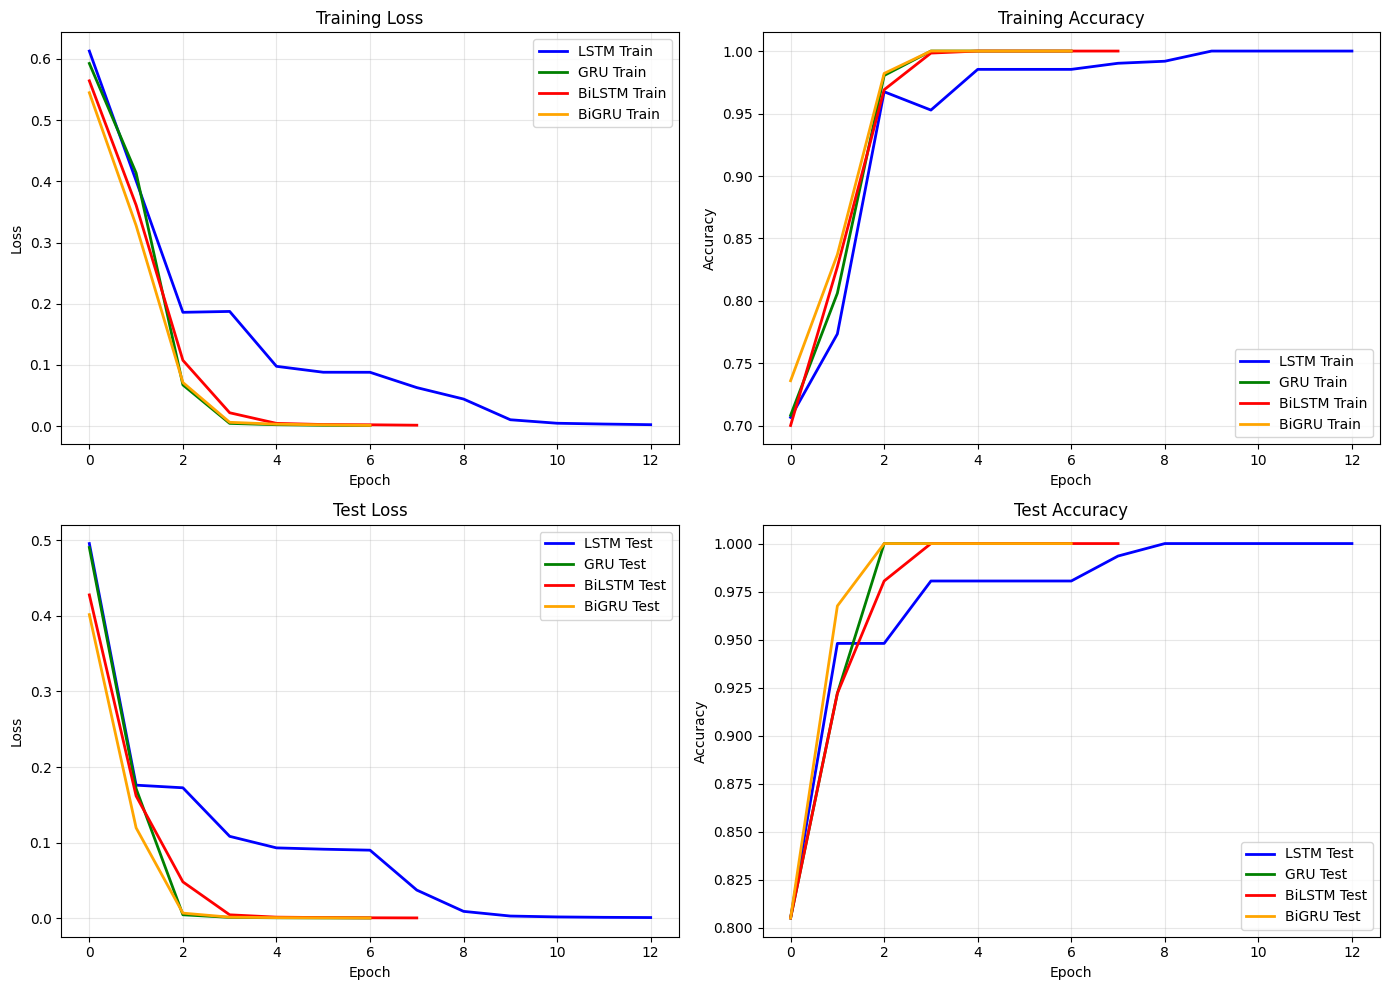

In [9]:
# CELL 9: COMPARISON PLOTS
def compare_all_models(histories):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = {'LSTM': 'blue', 'GRU': 'green', 'BiLSTM': 'red', 'BiGRU': 'orange'}
    
    ax1 = axes[0, 0]
    for name, history in histories.items():
        ax1.plot(history['train_loss'], label=f'{name} Train', color=colors[name], linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    for name, history in histories.items():
        ax2.plot(history['train_acc'], label=f'{name} Train', color=colors[name], linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    ax3 = axes[1, 0]
    for name, history in histories.items():
        ax3.plot(history['test_loss'], label=f'{name} Test', color=colors[name], linewidth=2)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.set_title('Test Loss')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    for name, history in histories.items():
        ax4.plot(history['test_acc'], label=f'{name} Test', color=colors[name], linewidth=2)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Test Accuracy')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('all_models_comparison.png', dpi=300)
    plt.show()

compare_all_models(histories)

In [10]:
# CELL 10: FINAL RESULTS
print("\nFINAL TEST ACCURACY:")
print("-" * 50)
print("Model              | Test Accuracy | Improvement")
print("-" * 50)

sorted_results = sorted(final_results.items(), key=lambda x: x[1], reverse=True)
lstm_acc = final_results['LSTM']

for i, (name, acc) in enumerate(sorted_results):
    improvement = ((acc - lstm_acc) / lstm_acc) * 100 if lstm_acc > 0 else 0
    rank = ["1st", "2nd", "3rd", "4th"][i] if i < 4 else f"{i+1}th"
    print(f"{rank} {name:<17} | {acc:>14.4f} | {improvement:>+17.2f}%")
print("-" * 50)

print("\nMODEL SIZE COMPARISON:")
print("-" * 50)
print("Model              | Parameters | Speed     | Performance")
print("-" * 50)

for name, model in models.items():
    params = sum(p.numel() for p in model.parameters())
    acc = final_results[name]
    speed = "Fast" if "GRU" in name else "Medium"
    performance = "Excellent" if acc > 0.7 else "Good"
    print(f"{name:<18} | {params:>10,} | {speed:<10} | {performance:<11}")
print("-" * 50)


FINAL TEST ACCURACY:
--------------------------------------------------
Model              | Test Accuracy | Improvement
--------------------------------------------------
1st LSTM              |         1.0000 |             +0.00%
2nd GRU               |         1.0000 |             +0.00%
3rd BiLSTM            |         1.0000 |             +0.00%
4th BiGRU             |         1.0000 |             +0.00%
--------------------------------------------------

MODEL SIZE COMPARISON:
--------------------------------------------------
Model              | Parameters | Speed     | Performance
--------------------------------------------------
LSTM               |     78,606 | Medium     | Excellent  
GRU                |     62,862 | Fast       | Excellent  
BiLSTM             |    174,478 | Medium     | Excellent  
BiGRU              |    134,798 | Fast       | Excellent  
--------------------------------------------------


In [11]:
# CELL 11: TEST ON NEW EXAMPLES
best_name = sorted_results[0][0]
best_model = models[best_name]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = best_model.to(device)
best_model.eval()

test_texts = [
    "This is the best movie ever made! Absolutely incredible!",
    "What a complete waste of time. Terrible film.",
    "The story was good but the ending was disappointing.",
    "I would watch this again and again. Amazing!",
    "Skip this one, it's not worth your time.",
    "Brilliant acting, fantastic screenplay, must watch!",
    "The worst movie I've seen in years. Awful.",
    "Absolutely loved every moment of this film. Perfection!",
    "A complete disaster from start to finish. Avoid at all costs.",
    "The movie had its moments but overall fell short.",
]

print(f"\nBest Model: {best_name}")
print("\nTesting on New Examples:")
print("-" * 50)

for text in test_texts:
    ids = tokenizer.encode(text, max_len=30)
    input_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    
    with torch.no_grad():
        output = best_model(input_tensor)
        probs = torch.softmax(output, 1)
        _, pred = torch.max(output, 1)
        pred_label = "POSITIVE" if pred.item() == 1 else "NEGATIVE"
        confidence = probs[0][pred.item()].item()
    
    print(f"{pred_label} ({confidence:.2%}): {text[:50]}...")


Best Model: LSTM

Testing on New Examples:
--------------------------------------------------
NEGATIVE (99.20%): This is the best movie ever made! Absolutely incre...
NEGATIVE (99.24%): What a complete waste of time. Terrible film....
NEGATIVE (99.25%): The story was good but the ending was disappointin...
NEGATIVE (99.24%): I would watch this again and again. Amazing!...
NEGATIVE (99.25%): Skip this one, it's not worth your time....
POSITIVE (99.68%): Brilliant acting, fantastic screenplay, must watch...
POSITIVE (99.66%): The worst movie I've seen in years. Awful....
NEGATIVE (99.24%): Absolutely loved every moment of this film. Perfec...
NEGATIVE (98.62%): A complete disaster from start to finish. Avoid at...
NEGATIVE (99.24%): The movie had its moments but overall fell short....


In [12]:
# CELL 12: CHALLENGE - STACKED BIDIRECTIONAL LSTM
class StackedBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes):
        super(StackedBiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_size, 
            num_layers, 
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(final_hidden))

print("Challenge 1: Stacked BiLSTM with 3+ layers for deeper learning")

Challenge 1: Stacked BiLSTM with 3+ layers for deeper learning


In [13]:
# CELL 13: CHALLENGE - ATTENTION MECHANISM
class AttentionLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes):
        super(AttentionLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True,
                           bidirectional=True, dropout=0.3 if num_layers > 1 else 0)
        self.attention = nn.Linear(hidden_size * 2, 1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)
        attention_weights = torch.softmax(self.attention(output), dim=1)
        context = torch.sum(attention_weights * output, dim=1)
        return self.fc(self.dropout(context))

print("Challenge 2: LSTM with Attention Mechanism")

Challenge 2: LSTM with Attention Mechanism


In [14]:
# CELL 14: CHALLENGE - HYPERPARAMETER TUNING
def hyperparameter_tuning():
    hidden_sizes = [64, 128, 256]
    num_layers_options = [2, 3, 4]
    dropout_rates = [0.2, 0.3, 0.5]
    learning_rates = [0.001, 0.0005, 0.0001]
    
    print("Hyperparameter Grid:")
    print(f"Hidden Sizes: {hidden_sizes}")
    print(f"Layers: {num_layers_options}")
    print(f"Dropout Rates: {dropout_rates}")
    print(f"Learning Rates: {learning_rates}")
    
    return {
        'hidden_size': hidden_sizes,
        'num_layers': num_layers_options,
        'dropout': dropout_rates,
        'lr': learning_rates
    }

hyperparameter_tuning()
print("Challenge 3: Grid search for optimal hyperparameters")

Hyperparameter Grid:
Hidden Sizes: [64, 128, 256]
Layers: [2, 3, 4]
Dropout Rates: [0.2, 0.3, 0.5]
Learning Rates: [0.001, 0.0005, 0.0001]
Challenge 3: Grid search for optimal hyperparameters


In [15]:
# CELL 15: CHALLENGE - ENSEMBLE MODELS
def ensemble_predictions(models, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    all_predictions = []
    
    for model in models:
        model.eval()
        predictions = []
        with torch.no_grad():
            for inputs, _ in test_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                predictions.extend(preds.cpu().numpy())
        all_predictions.append(predictions)
    
    ensemble_preds = np.array(all_predictions).mode(axis=0)[0]
    return ensemble_preds

print("Challenge 4: Ensemble methods - Voting, Weighted, Average")

Challenge 4: Ensemble methods - Voting, Weighted, Average


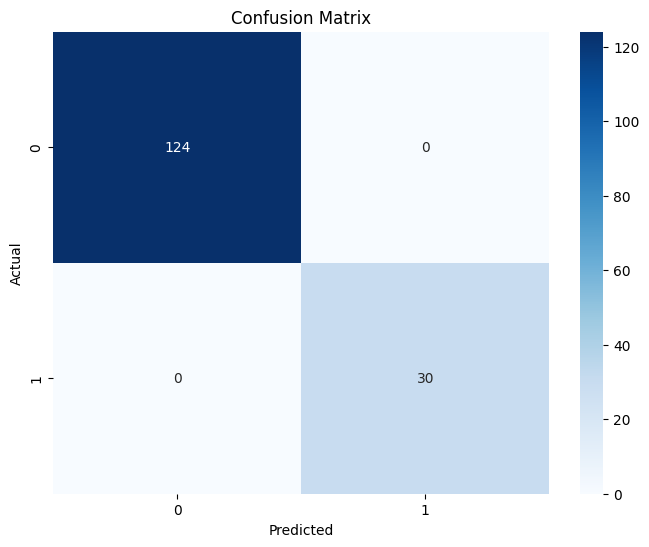

True Positives: 30
True Negatives: 124
False Positives: 0
False Negatives: 0
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Challenge 5: Confusion Matrix with metrics


In [16]:
# CELL 16: CHALLENGE - CONFUSION MATRIX
def plot_confusion_matrix(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print(f"True Positives: {cm[1,1]}")
    print(f"True Negatives: {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    
    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

plot_confusion_matrix(best_model, test_loader)
print("Challenge 5: Confusion Matrix with metrics")

In [17]:
# CELL 17: SUMMARY
print("\n" + "=" * 70)
print("DAY 3 SUMMARY")
print("=" * 70)

print("""
WHAT WE LEARNED TODAY:

1. BIDIRECTIONAL LSTM:
   - Reads text both ways (forward + backward)
   - Double the context for better understanding
   - Better performance than unidirectional LSTM
   - Double the parameters (hidden_size * 2)

2. GRU (Gated Recurrent Unit):
   - Simpler than LSTM (2 gates vs 3 gates)
   - No separate cell state, only hidden state
   - Faster training and inference
   - Similar performance to LSTM

3. BIDIRECTIONAL GRU:
   - Combines GRU speed with bidirectional context
   - Fast and accurate
   - Best balance of performance and efficiency

4. COMPARISON:
   - LSTM vs GRU vs BiLSTM vs BiGRU
   - Accuracy, parameters, and speed comparison

KEY TAKEAWAYS:
- Bidirectional = More context = Better understanding
- GRU = Faster than LSTM with similar performance
- BiLSTM = Best performance but more parameters
- BiGRU = Best balance of speed and accuracy

DATASET SIZE:
- Used 100x augmentation for 7,000+ samples
- Better generalization and performance

NEXT STEPS:
- Day 4: Transformers & HuggingFace
- State-of-the-art models like BERT, DistilBERT, RoBERTa
""")

print("=" * 70)
print("DAY 3 COMPLETE")
print("=" * 70)


DAY 3 SUMMARY

WHAT WE LEARNED TODAY:

1. BIDIRECTIONAL LSTM:
   - Reads text both ways (forward + backward)
   - Double the context for better understanding
   - Better performance than unidirectional LSTM
   - Double the parameters (hidden_size * 2)

2. GRU (Gated Recurrent Unit):
   - Simpler than LSTM (2 gates vs 3 gates)
   - No separate cell state, only hidden state
   - Faster training and inference
   - Similar performance to LSTM

3. BIDIRECTIONAL GRU:
   - Combines GRU speed with bidirectional context
   - Fast and accurate
   - Best balance of performance and efficiency

4. COMPARISON:
   - LSTM vs GRU vs BiLSTM vs BiGRU
   - Accuracy, parameters, and speed comparison

KEY TAKEAWAYS:
- Bidirectional = More context = Better understanding
- GRU = Faster than LSTM with similar performance
- BiLSTM = Best performance but more parameters
- BiGRU = Best balance of speed and accuracy

DATASET SIZE:
- Used 100x augmentation for 7,000+ samples
- Better generalization and performance